### Neural Computing Individual Project: MLP Model Testing 

In [13]:
import numpy as np
import torch
import torch.nn as nn
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import seaborn as sns

In [14]:
# LOAD TEST SET
X_test = np.load('submission_files/X_test.npy')
y_test = np.load('submission_files/y_test.npy')
print(f"Test set loaded: {X_test.shape[0]} samples, {X_test.shape[1]} features")

Test set loaded: 114 samples, 30 features


In [15]:
# MLP MODEL DEFINITION
# Matching the architecture used during training
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2):
        super(MLP, self).__init__()
        self.fc1     = nn.Linear(30, hidden_dim1)
        self.fc2     = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3     = nn.Linear(hidden_dim2, 1)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.sigmoid(self.fc3(x))

In [16]:
# LOAD AND EVALUATE MLP
mlp_scaler = joblib.load('submission_files/mlp_scaler.pkl')
X_test_scaled_mlp = mlp_scaler.transform(X_test)
X_test_t = torch.tensor(X_test_scaled_mlp, dtype=torch.float32)

# Instantiate model with the best architecture found during training
mlp_model = MLP(input_dim=30, hidden_dim1=32, hidden_dim2=16)
mlp_model.load_state_dict(torch.load('submission_files/mlp_best_weights.pt',weights_only=True))
mlp_model.eval()

with torch.no_grad():
    mlp_probs = mlp_model(X_test_t)
    mlp_preds = (mlp_probs >= 0.5).float().numpy().flatten()

mlp_accuracy  = accuracy_score(y_test,  mlp_preds)
mlp_precision = precision_score(y_test, mlp_preds)
mlp_recall    = recall_score(y_test,    mlp_preds)
mlp_f1        = f1_score(y_test,        mlp_preds)

print("MLP Test Set Performance")
print(f"  Accuracy  : {mlp_accuracy:.4f}")
print(f"  Precision : {mlp_precision:.4f}")
print(f"  Recall    : {mlp_recall:.4f}")
print(f"  F1 Score  : {mlp_f1:.4f}")

MLP Test Set Performance
  Accuracy  : 0.9737
  Precision : 0.9726
  Recall    : 0.9861
  F1 Score  : 0.9793


### Reproducing Figures

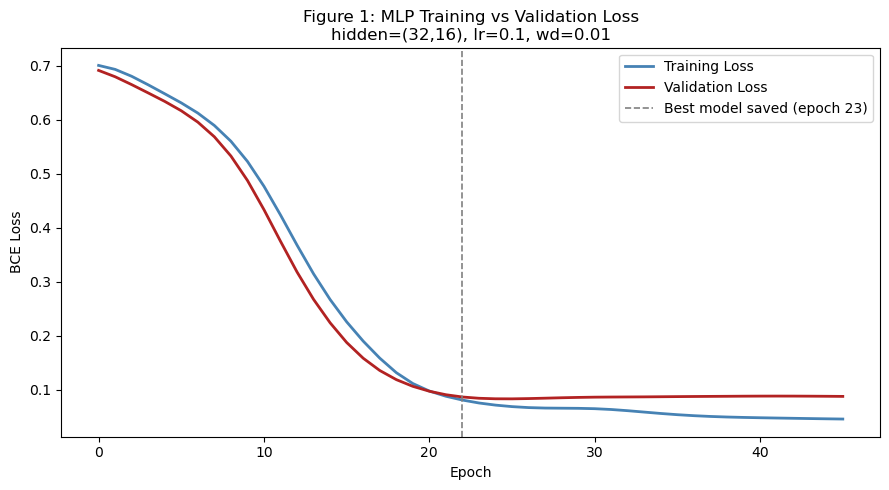

In [20]:
# FIGURE 1: FINAL MODEL MLP LOSS CURVES 
# Loaded from saved training history 

train_losses_mlp = np.load('submission_files/mlp_train_losses.npy')
val_losses_mlp   = np.load('submission_files/mlp_val_losses.npy')
best_epoch_mlp   = int(np.load('submission_files/mlp_best_epoch.npy'))

plt.figure(figsize=(9, 5))
plt.plot(train_losses_mlp, label='Training Loss',   color='steelblue', linewidth=2)
plt.plot(val_losses_mlp,   label='Validation Loss', color='firebrick',  linewidth=2)
plt.axvline(x=best_epoch_mlp,
            color='grey', linestyle='--', linewidth=1.2,
            label=f'Best model saved (epoch {best_epoch_mlp + 1})')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Figure 1: MLP Training vs Validation Loss\n'
          'hidden=(32,16), lr=0.1, wd=0.01')
plt.legend()
plt.tight_layout()
plt.show()

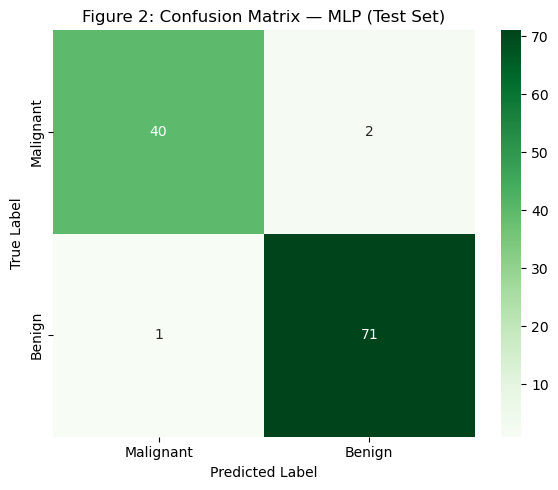

In [19]:
# FIGURE 2: MLP CONFUSION MATRIX 
# Load saved weights and evaluate on test set 
mlp_scaler    = joblib.load('submission_files/mlp_scaler.pkl')
X_test        = np.load('submission_files/X_test.npy')
y_test        = np.load('submission_files/y_test.npy')
X_test_scaled = mlp_scaler.transform(X_test)
X_test_t      = torch.tensor(X_test_scaled, dtype=torch.float32)

mlp_model = MLP(input_dim=30, hidden_dim1=32, hidden_dim2=16)
mlp_model.load_state_dict(torch.load('submission_files/mlp_best_weights.pt',
                                      weights_only=True))
mlp_model.eval()

with torch.no_grad():
    mlp_preds = (mlp_model(X_test_t) >= 0.5).float().numpy().flatten()

cm = confusion_matrix(y_test, mlp_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Figure 2: Confusion Matrix — MLP (Test Set)')
plt.tight_layout()
plt.show()